In [1]:
import pandas as pd
import re

def parse_can_log(file_path):
    """Parse CAN log file and return a pandas DataFrame"""
    data = []
    
    with open(file_path, 'r') as f:
        for line in f:
            # Extract fields using regex
            match = re.search(r'Timestamp:\s([\d.]+)\s+ID:\s(\w+)\s+(\w+)\s+DLC:\s(\d+)\s+(.*)', line)
            if match:
                timestamp, can_id, flags, dlc, hex_data = match.groups()
                data.append({
                    'Timestamp': float(timestamp),
                    'ID': can_id,
                    'Flags': flags,
                    'DLC': int(dlc),
                    'Data': hex_data.strip()
                })
    
    df = pd.DataFrame(data)
    return df

# Usage
df = parse_can_log('dataset\\normal_run_data\\normal_run_data.txt')
print(df)

           Timestamp    ID Flags  DLC                     Data
0       1.479121e+09  0350   000    8  05 28 84 66 6d 00 00 a2
1       1.479121e+09  02c0   000    8  14 00 00 00 00 00 00 00
2       1.479121e+09  0430   000    8  00 00 00 00 00 00 00 00
3       1.479121e+09  04b1   000    8  00 00 00 00 00 00 00 00
4       1.479121e+09  01f1   000    8  00 00 00 00 00 00 00 00
...              ...   ...   ...  ...                      ...
988866  1.479122e+09  02b0   000    5           ac 05 0c 07 7f
988867  1.479122e+09  0316   000    8  05 38 10 0c 38 28 01 7a
988868  1.479122e+09  018f   000    8  fe 31 00 00 00 4b 00 00
988869  1.479122e+09  0260   000    8  32 38 39 30 ff 93 59 1c
988870  1.479122e+09  02a0   000    8  20 00 75 1d 01 04 dd 00

[988871 rows x 5 columns]


In [2]:
def parse_can_csv(file_path):
    df_can = pd.read_csv(file_path, skipinitialspace=True)

    if 'ID dlc' in df_can.columns:
        df_can[['ID', 'DLC']] = df_can['ID dlc'].astype(str).str.split(r'\s+', n=1, expand=True)
        df_can = df_can.drop(columns=['ID dlc'])
    elif set(['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','attack/nonattack']).issubset(df_can.columns):
        df_can = df_can.rename(columns={'attack/nonattack': 'Attack'})
    else:
        names = ['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','Attack']
        df_can = pd.read_csv(file_path, header=None, names=names, skipinitialspace=True)

    unnamed = [c for c in df_can.columns if isinstance(c, str) and c.startswith('Unnamed')]
    if 'Attack' not in df_can.columns and unnamed:
        df_can = df_can.rename(columns={unnamed[-1]: 'Attack'})

    data_cols = sorted(
        [c for c in df_can.columns if isinstance(c, str) and c.lower().startswith('data')],
        key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0
    )

    def build_data(row):
        try:
            dlc = int(row['DLC'])
        except Exception:
            dlc = 0

        values = []
        for col in data_cols[:min(dlc, len(data_cols))]:
            val = row.get(col)
            if pd.isna(val):
                continue
            s = str(val).strip()
            if s.lower() in ['', 'nan']:
                continue
            values.append(s)

        return ' '.join(values).strip()

    def infer_attack(row):
        attack = row.get('Attack')
        if isinstance(attack, str) and attack.strip():
            return attack

        try:
            dlc = int(row['DLC'])
        except Exception:
            dlc = 0

        for col in data_cols[min(dlc, len(data_cols)):]:
            val = row.get(col)
            if pd.isna(val):
                continue
            s = str(val).strip()
            if s.lower() in ['', 'nan']:
                continue
            if not re.fullmatch(r'[0-9A-Fa-f]{2}', s):
                return s

        return pd.NA

    if data_cols:
        df_can['Data'] = df_can.apply(build_data, axis=1)
        if 'Attack' not in df_can.columns:
            df_can['Attack'] = pd.NA
        df_can['Attack'] = df_can.apply(infer_attack, axis=1).combine_first(df_can['Attack'])
    else:
        df_can['Data'] = df_can.get('Data', '').astype(str).str.strip()
        if 'Attack' not in df_can.columns:
            df_can['Attack'] = pd.NA

    df_can['Timestamp'] = pd.to_numeric(df_can['Timestamp'], errors='coerce')
    df_can['DLC'] = pd.to_numeric(df_can['DLC'], errors='coerce').astype('Int64')

    return df_can[['Timestamp','ID','DLC','Data','Attack']]

In [ ]:
df_DoS = parse_can_csv(r'dataset\DoS_dataset.csv')
print(df_DoS.head())

      Timestamp    ID  DLC                     Data Attack
0  1.478198e+09  0316    8  05 21 68 09 21 21 00 6f      R
1  1.478198e+09  018f    8  fe 5b 00 00 00 3c 00 00      R
2  1.478198e+09  0260    8  19 21 22 30 08 8e 6d 3a      R
3  1.478198e+09  02a0    8  64 00 9a 1d 97 02 bd 00      R
4  1.478198e+09  0329    8  40 bb 7f 14 11 20 00 14      R


In [4]:
df_Fuzzy = parse_can_csv(r'dataset\Fuzzy_dataset.csv')
print(df_Fuzzy.head())

      Timestamp    ID  DLC                     Data Attack
0  1.478196e+09  0545    8  d8 00 00 8a 00 00 00 00      R
1  1.478196e+09  02b0    5           ff 7f 00 05 49      R
2  1.478196e+09  0002    8  00 00 00 00 00 01 07 15      R
3  1.478196e+09  0153    8  00 21 10 ff 00 ff 00 00      R
4  1.478196e+09  0130    8  19 80 00 ff fe 7f 07 60      R


In [3]:
df_gear = parse_can_csv(r'dataset\gear_dataset.csv')
print(df_gear.head())

      Timestamp    ID  DLC                     Data Attack
0  1.478193e+09  0140    8  00 00 00 00 10 29 2a 24      R
1  1.478193e+09  02c0    8  15 00 00 00 00 00 00 00      R
2  1.478193e+09  0350    8  05 20 44 68 77 00 00 7e      R
3  1.478193e+09  0370    8  00 20 00 00 00 00 00 00      R
4  1.478193e+09  043f    8  10 40 60 ff 78 c4 08 00      R


In [6]:
df_RPM = parse_can_csv(r'dataset\RPM_dataset.csv')
print(df_RPM.head())

      Timestamp    ID  DLC                     Data Attack
0  1.478191e+09  0316    8  05 22 68 09 22 20 00 75      R
1  1.478191e+09  018f    8  fe 3b 00 00 00 3c 00 00      R
2  1.478191e+09  0260    8  19 22 22 30 ff 8f 6e 3f      R
3  1.478191e+09  02a0    8  60 00 83 1d 96 02 bd 00      R
4  1.478191e+09  0329    8  dc b8 7e 14 11 20 00 14      R


In [4]:
import numpy as np

def sliding_windows_id_data(df, window_size=8, step=2):
    ids = df['ID'].to_numpy(dtype=object)
    data = df['Data'].to_numpy(dtype=object)
    attack = df['Attack'].to_numpy(dtype=object)

    n = len(df)
    num_windows = (n - window_size) // step + 1
    windows = []
    window_labels = []

    for start in range(0, n - window_size + 1, step):
        end = start + window_size
        windows.append(np.column_stack((ids[start:end], data[start:end])))
        window_labels.append('T' if 'T' in attack[start:end] else 'R')

    return windows, np.array(window_labels, dtype=object)

windowed_id_data, window_attack_labels = sliding_windows_id_data(df_gear)
print(len(windowed_id_data), window_attack_labels[:10])

2221568 ['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R']


In [5]:
print(len(windowed_id_data), windowed_id_data[:10])

2221568 [array([['0140', '00 00 00 00 10 29 2a 24'],
       ['02c0', '15 00 00 00 00 00 00 00'],
       ['0350', '05 20 44 68 77 00 00 7e'],
       ['0370', '00 20 00 00 00 00 00 00'],
       ['043f', '10 40 60 ff 78 c4 08 00'],
       ['0440', 'ff 00 00 00 ff c4 08 00'],
       ['0316', '05 21 68 09 21 21 00 70'],
       ['018f', 'fe 50 00 00 00 3c 00 00']], dtype=object), array([['0350', '05 20 44 68 77 00 00 7e'],
       ['0370', '00 20 00 00 00 00 00 00'],
       ['043f', '10 40 60 ff 78 c4 08 00'],
       ['0440', 'ff 00 00 00 ff c4 08 00'],
       ['0316', '05 21 68 09 21 21 00 70'],
       ['018f', 'fe 50 00 00 00 3c 00 00'],
       ['0002', '00 00 00 00 00 06 0b 70'],
       ['0153', '00 21 10 ff 00 ff 00 00']], dtype=object), array([['043f', '10 40 60 ff 78 c4 08 00'],
       ['0440', 'ff 00 00 00 ff c4 08 00'],
       ['0316', '05 21 68 09 21 21 00 70'],
       ['018f', 'fe 50 00 00 00 3c 00 00'],
       ['0002', '00 00 00 00 00 06 0b 70'],
       ['0153', '00 21 10 ff 00 ff 

In [6]:
def _hex_byte_list_from_row(row):
    msg_id, data = row
    msg_id = str(msg_id).strip()
    if len(msg_id) % 2 != 0:
        msg_id = '0' + msg_id
    id_bytes = [msg_id[i:i+2] for i in range(0, len(msg_id), 2)]
    data_bytes = [b for b in str(data).split() if b]
    return [int(b, 16) for b in id_bytes + data_bytes]

def convert_windowed_id_data_to_ints(windowed_data, pad_value=0):
    int_windows = []
    for window in windowed_data:
        rows = [_hex_byte_list_from_row(row) for row in window]
        max_len = max(len(r) for r in rows)
        padded_rows = [r + [pad_value] * (max_len - len(r)) for r in rows]
        int_windows.append(np.array(padded_rows, dtype=np.uint8))
    return int_windows

int_windowed_id_data = convert_windowed_id_data_to_ints(windowed_id_data)

print(int_windowed_id_data[0].shape)
print(int_windowed_id_data[0][:2])

(8, 10)
[[  1  64   0   0   0   0  16  41  42  36]
 [  2 192  21   0   0   0   0   0   0   0]]


In [7]:
int_windowed_id_data

[array([[  1,  64,   0,   0,   0,   0,  16,  41,  42,  36],
        [  2, 192,  21,   0,   0,   0,   0,   0,   0,   0],
        [  3,  80,   5,  32,  68, 104, 119,   0,   0, 126],
        [  3, 112,   0,  32,   0,   0,   0,   0,   0,   0],
        [  4,  63,  16,  64,  96, 255, 120, 196,   8,   0],
        [  4,  64, 255,   0,   0,   0, 255, 196,   8,   0],
        [  3,  22,   5,  33, 104,   9,  33,  33,   0, 112],
        [  1, 143, 254,  80,   0,   0,   0,  60,   0,   0]], dtype=uint8),
 array([[  3,  80,   5,  32,  68, 104, 119,   0,   0, 126],
        [  3, 112,   0,  32,   0,   0,   0,   0,   0,   0],
        [  4,  63,  16,  64,  96, 255, 120, 196,   8,   0],
        [  4,  64, 255,   0,   0,   0, 255, 196,   8,   0],
        [  3,  22,   5,  33, 104,   9,  33,  33,   0, 112],
        [  1, 143, 254,  80,   0,   0,   0,  60,   0,   0],
        [  0,   2,   0,   0,   0,   0,   0,   6,  11, 112],
        [  1,  83,   0,  33,  16, 255,   0, 255,   0,   0]], dtype=uint8),
 array([[ 

In [8]:
flattened_int_windowed_id_data = [window.ravel() for window in int_windowed_id_data]

# verify each window flattened to 80 bytes
assert all(arr.size == 80 for arr in flattened_int_windowed_id_data)

print(flattened_int_windowed_id_data[0].shape)
print(flattened_int_windowed_id_data[0])

(80,)
[  1  64   0   0   0   0  16  41  42  36   2 192  21   0   0   0   0   0
   0   0   3  80   5  32  68 104 119   0   0 126   3 112   0  32   0   0
   0   0   0   0   4  63  16  64  96 255 120 196   8   0   4  64 255   0
   0   0 255 196   8   0   3  22   5  33 104   9  33  33   0 112   1 143
 254  80   0   0   0  60   0   0]


In [9]:
window_attack_onehot = np.zeros((len(window_attack_labels), 2), dtype=np.uint8)
window_attack_onehot[window_attack_labels == 'R', 0] = 1
window_attack_onehot[window_attack_labels == 'T', 1] = 1

print(window_attack_onehot[:10])

[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]]


In [10]:
len(flattened_int_windowed_id_data)

2221568

In [11]:
len(window_attack_onehot)

2221568

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split

# prepare arrays
X = np.stack(flattened_int_windowed_id_data)  # shape (N, 80)
y = window_attack_onehot

# attempt stratified split, fallback if stratify not possible
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print("X_train:", X_train.shape, "X_test:", X_test.shape, "y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (1777254, 80) X_test: (444314, 80) y_train: (1777254, 2) y_test: (444314, 2)


In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Dense(64, activation="sigmoid", input_shape=(80,)), 
    Dense(32, activation='sigmoid'), 
    Dense(2, activation='softmax'),  
])

c:\Users\garet\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

mod = model.fit(X_train, y_train, epochs=10, 
          batch_size=2000, 
          validation_split=0.2)
          
print(mod)

Epoch 1/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9395 - loss: 0.1577 - val_accuracy: 0.9678 - val_loss: 0.0880
Epoch 2/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9732 - loss: 0.0750 - val_accuracy: 0.9761 - val_loss: 0.0661
Epoch 3/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9791 - loss: 0.0589 - val_accuracy: 0.9807 - val_loss: 0.0543
Epoch 4/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9825 - loss: 0.0497 - val_accuracy: 0.9835 - val_loss: 0.0467
Epoch 5/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9851 - loss: 0.0425 - val_accuracy: 0.9858 - val_loss: 0.0403
Epoch 6/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9877 - loss: 0.0356 - val_accuracy: 0.9889 - val_loss: 0.0326
Epoch 7/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9902 - loss: 0.0288 - val_accuracy: 0.9911 - val_loss: 0.0264
Epoch 8/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9921 - loss: 0.0232 - val_accuracy: 0.

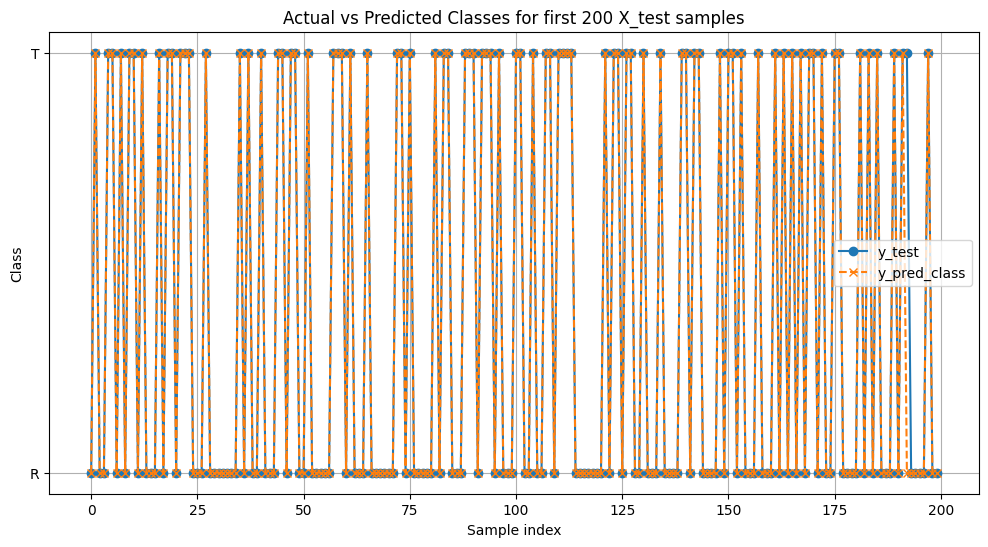

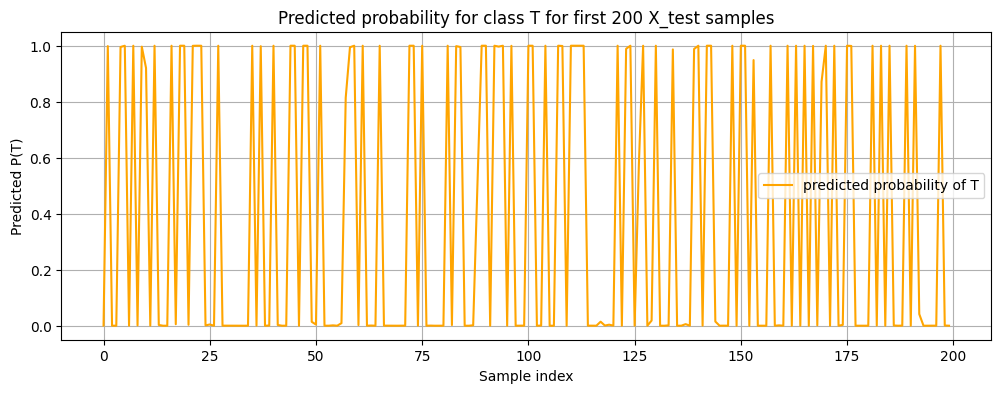

In [16]:
y_pred = model.predict(X_test, batch_size=2000, verbose=0)
y_pred_class = np.argmax(y_pred, axis=1)
y_test_class = np.argmax(y_test, axis=1)

n = min(200, X_test.shape[0])

plt.figure(figsize=(12, 6))
plt.plot(range(n), y_test_class[:n], label='y_test', marker='o', linestyle='-')
plt.plot(range(n), y_pred_class[:n], label='y_pred_class', marker='x', linestyle='--')
plt.yticks([0, 1], ['R', 'T'])
plt.xlabel('Sample index')
plt.ylabel('Class')
plt.title(f'Actual vs Predicted Classes for first {n} X_test samples')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(range(n), y_pred[:n, 1], label='predicted probability of T', color='orange')
plt.xlabel('Sample index')
plt.ylabel('Predicted P(T)')
plt.title(f'Predicted probability for class T for first {n} X_test samples')
plt.legend()
plt.grid(True)
plt.show()